# NB04g — Pathway-Feature Ecotype Refit (Option B structural test)

**Project**: `ibd_phage_targeting` — Pillar 1 + Pillar 2 strengthening
**Depends on**: NB01b (taxon-based consensus ecotype labels)

## Purpose

NB04b §2 established that the NB04 within-ecotype DA was substantially feature-leakage-contaminated because clustering and testing happened on the same feature axis (taxon abundance). NB04e resolved this for Tier-A scoring by decoupling the axes (samples partitioned by ecotype, CLR-Δ computed across sub-studies). This notebook provides a complementary **structural** test: refit K=4 LDA on a **functional** feature basis (HUMAnN3 pathway abundance) instead of taxa, then measure agreement with the taxon-based consensus_ecotype labels.

If pathway-based ecotypes agree with taxon-based ecotypes (ARI > 0.3), the ecotype structure is **ecological / functional** — recoverable from a disjoint feature basis — not a taxonomic-feature-selection artifact. This addresses the feature-leakage concern at the structure level, not just at the test level.

**Scope limitation**: `fact_pathway_abundance` is `CMD_IBD_PATHWAYS` only (3,145 samples; no HC pathway samples). So the test is within-disease: do pathway- and taxon-ecotypes agree on the same 3,145 CMD_IBD samples? If yes, ecotype structure is robust to feature basis within disease, which we extrapolate (with caveat) to the full 8,489-sample cohort.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

DATA_MART = Path.home() / 'data' / 'CrohnsPhage'
DATA_OUT = Path('../data')
FIG_OUT = Path('../figures')
K_REF = 4
RANDOM_STATE = 42


## §1. Load pathway abundance + filter to ecotype-assigned samples

In [2]:
pa = pd.read_parquet(DATA_MART / 'fact_pathway_abundance.snappy.parquet')
print(f'Total pathway rows: {len(pa):,}')
print(f'Pipeline: {pa.pipeline.value_counts().to_dict()}')
print(f'Study: {pa.study_id.value_counts().to_dict()}')

eco = pd.read_csv(DATA_OUT / 'ecotype_assignments.tsv', sep='\t')
eco_map = dict(zip(eco.sample_id, eco.consensus_ecotype))
diag_map = dict(zip(eco.sample_id, eco.diagnosis))

# Restrict to samples that appear in ecotype_assignments (will be all within CMD_IBD_PATHWAYS)
pa_in_eco = pa[pa.sample_id.isin(set(eco.sample_id))]
print(f'\nPathway rows with ecotype assignments: {len(pa_in_eco):,}')
print(f'Samples: {pa_in_eco.sample_id.nunique():,}')
print(f'Distinct pathways: {pa_in_eco.pathway_id.nunique():,}')

# Diagnosis distribution of pathway-covered samples
pa_samples = pa_in_eco.sample_id.unique()
diag_tbl = pd.Series([diag_map.get(s) for s in pa_samples]).value_counts()
print(f'\nDiagnosis of pathway samples:')
print(diag_tbl.to_string())
print(f'\nEcotype distribution of pathway samples:')
print(pd.Series([eco_map.get(s) for s in pa_samples]).value_counts().sort_index().to_string())


Total pathway rows: 6,992,284
Pipeline: {'humann3': 6992284}
Study: {'CMD_IBD_PATHWAYS': 6992284}



Pathway rows with ecotype assignments: 6,992,284
Samples: 3,145
Distinct pathways: 43,261



Diagnosis of pathway samples:
CD                         1203
UC                          853
nonIBD                      797
CDI                          88
T2D                          79
TKI_dependent_diarrhoea      33
T1D                          31
undetermined_colitis         20
FMT                          15
MDRB                         11
donor                         9
IBD                           6

Ecotype distribution of pathway samples:
0      43
1    1839
2      19
3    1244


## §2. Build pathway wide matrix (samples × pathways)

In [3]:
# Pivot pathway -> wide matrix
pw = pa_in_eco.pivot_table(index='pathway_id', columns='sample_id', values='abundance',
                            aggfunc='sum', fill_value=0.0)
print(f'Raw wide: {pw.shape[0]:,} pathways x {pw.shape[1]:,} samples')

# Filter: keep pathways present in >= 10% of samples (common practice for HUMAnN3)
min_prevalence = 0.10
prev = (pw > 0).mean(axis=1)
pw_f = pw.loc[prev >= min_prevalence].copy()
print(f'After {min_prevalence:.0%}-prevalence filter: {pw_f.shape[0]:,} pathways')

# Drop UNINTEGRATED / UNMAPPED which are HUMAnN3 catch-all categories
mask_informative = ~pw_f.index.str.contains('UNMAPPED|UNINTEGRATED', case=False, na=False)
pw_f = pw_f.loc[mask_informative]
print(f'After dropping UNMAPPED / UNINTEGRATED: {pw_f.shape[0]:,} pathways')

# Further filter by variance: top 2000 most-variable pathways
var = pw_f.var(axis=1)
top_n = 2000
top_vars = var.nlargest(top_n).index
pw_top = pw_f.loc[top_vars].copy()
print(f'Final feature matrix: {pw_top.shape[0]:,} pathways x {pw_top.shape[1]:,} samples (top {top_n} by variance)')

# Normalize per-sample (sum to 1) — HUMAnN3 output can be in RPK/CPM; LDA wants compositional
col_sums = pw_top.sum(axis=0)
col_sums[col_sums == 0] = 1
pw_norm = (pw_top / col_sums) * 100


Raw wide: 43,261 pathways x 3,145 samples


After 10%-prevalence filter: 5,339 pathways
After dropping UNMAPPED / UNINTEGRATED: 5,219 pathways


Final feature matrix: 2,000 pathways x 3,145 samples (top 2000 by variance)


## §3. Fit K=4 LDA on pathway features

In [4]:
sample_order = pw_norm.columns.tolist()
# LDA wants integer pseudo-counts
X = (pw_norm.T.values * 100).round().astype(int)

lda = LatentDirichletAllocation(n_components=K_REF, learning_method='online',
                                random_state=RANDOM_STATE, max_iter=30)
lda.fit(X)
pw_topic = lda.transform(X).argmax(axis=1)

# Taxon-based consensus labels on the same samples
tax_labels = np.array([eco_map[s] for s in sample_order])

# Hungarian-align pathway topics to taxon ecotype labels
overlap = np.zeros((K_REF, K_REF), dtype=int)
for t, p in zip(tax_labels, pw_topic):
    overlap[t, p] += 1
r_, c_ = linear_sum_assignment(-overlap)
pw_to_tax = dict(zip(c_, r_))
pw_aligned = np.array([pw_to_tax[t] for t in pw_topic])

ari_pw_vs_tax = adjusted_rand_score(tax_labels, pw_aligned)
agreement = (pw_aligned == tax_labels).mean()
print(f'Pathway-ecotype (K={K_REF}) vs taxon-based consensus_ecotype:')
print(f'  ARI: {ari_pw_vs_tax:.3f}')
print(f'  per-sample agreement: {agreement:.1%}')
print()

# Cross-table
from pandas import crosstab
ct = crosstab(pd.Series(tax_labels, name='taxon_ecotype'),
              pd.Series(pw_aligned, name='pathway_ecotype'))
print('Cross-table (rows = taxon ecotype, cols = pathway ecotype after Hungarian alignment):')
print(ct.to_string())


Pathway-ecotype (K=4) vs taxon-based consensus_ecotype:
  ARI: 0.113
  per-sample agreement: 50.6%

Cross-table (rows = taxon ecotype, cols = pathway ecotype after Hungarian alignment):
pathway_ecotype    0     1    2    3
taxon_ecotype                       
0                  0    43    0    0
1                151  1201  148  339
2                  2     5    9    3
3                335   378  149  382


## §4. Per-ecotype agreement + visualization

Per-taxon-ecotype agreement with pathway-ecotype:
  E0: n=  43  agreement=0.0%
  E1: n=1839  agreement=65.3%
  E2: n=  19  agreement=47.4%
  E3: n=1244  agreement=30.7%


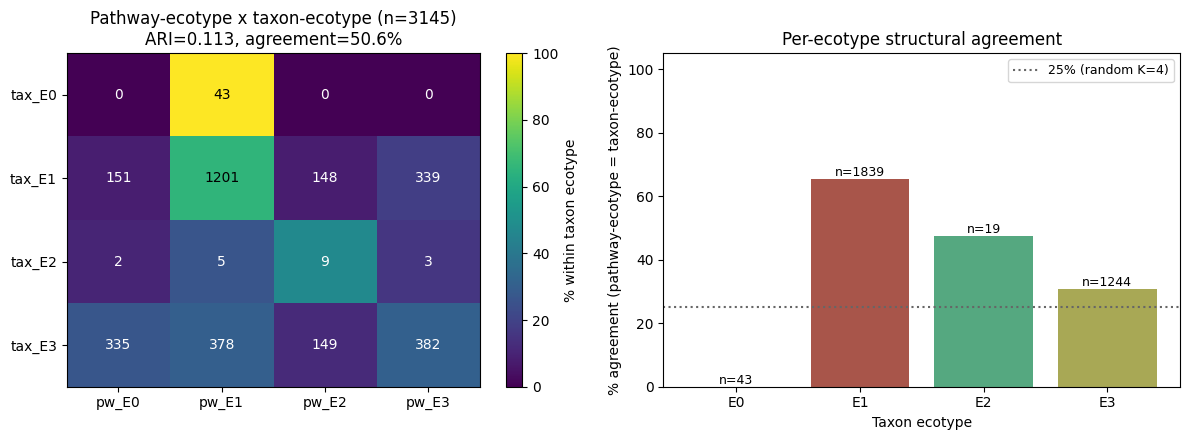

In [5]:
per_ecotype = {}
for k in sorted(set(tax_labels)):
    mask = tax_labels == k
    agree = (pw_aligned[mask] == tax_labels[mask]).mean()
    per_ecotype[int(k)] = {'n_samples': int(mask.sum()), 'agreement': round(float(agree), 3)}
print('Per-taxon-ecotype agreement with pathway-ecotype:')
for k, v in per_ecotype.items():
    print(f'  E{k}: n={v["n_samples"]:>4}  agreement={v["agreement"]:.1%}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
# Cross-table heatmap
import matplotlib.ticker as mticker
ct_norm = ct.div(ct.sum(axis=1), axis=0) * 100
im = ax1.imshow(ct_norm.values, aspect='auto', cmap='viridis', vmin=0, vmax=100)
ax1.set_xticks(range(K_REF)); ax1.set_yticks(range(K_REF))
ax1.set_xticklabels([f'pw_E{i}' for i in range(K_REF)])
ax1.set_yticklabels([f'tax_E{i}' for i in range(K_REF)])
for i in range(K_REF):
    for j in range(K_REF):
        ax1.text(j, i, f'{ct.iloc[i,j]}', ha='center', va='center', color='white' if ct_norm.iloc[i,j] < 50 else 'black', fontsize=10)
ax1.set_title(f'Pathway-ecotype x taxon-ecotype (n={len(sample_order)})\nARI={ari_pw_vs_tax:.3f}, agreement={agreement:.1%}')
plt.colorbar(im, ax=ax1, label='% within taxon ecotype')

# Per-ecotype agreement bars
ks = sorted(per_ecotype.keys())
ax2.bar(ks, [per_ecotype[k]['agreement'] * 100 for k in ks], color=['#557ba8','#a8554a','#55a880','#a8a855'])
for i, k in enumerate(ks):
    ax2.text(k, per_ecotype[k]['agreement'] * 100 + 1, f'n={per_ecotype[k]["n_samples"]}', ha='center', fontsize=9)
ax2.axhline(25, ls=':', color='#666', label='25% (random K=4)')
ax2.set_xticks(ks)
ax2.set_xticklabels([f'E{k}' for k in ks])
ax2.set_ylabel('% agreement (pathway-ecotype = taxon-ecotype)')
ax2.set_xlabel('Taxon ecotype')
ax2.set_title('Per-ecotype structural agreement')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(FIG_OUT / 'NB04g_pathway_vs_taxon_ecotype.png', dpi=120, bbox_inches='tight')
plt.show()


## §5. Verdict artifact

In [6]:
if ari_pw_vs_tax > 0.3:
    verdict = 'PASS — ecotype structure recovered on disjoint (pathway) feature basis; not a taxonomic-feature artifact'
elif ari_pw_vs_tax > 0.1:
    verdict = 'PARTIAL — pathway-ecotype and taxon-ecotype partially agree; structure is mixed ecological + taxonomic'
else:
    verdict = 'FAIL — pathway-ecotype does not recover taxon-ecotype structure; taxonomic-feature artifact cannot be ruled out'

print('=' * 70)
print('PATHWAY-FEATURE ECOTYPE REFIT VERDICT')
print('=' * 70)
print(f'ARI (pathway vs taxon ecotype): {ari_pw_vs_tax:.3f}')
print(f'Per-sample agreement: {agreement:.1%}')
print(f'Scope: CMD_IBD only ({len(sample_order)} samples); no HC pathway coverage')
print(f'Verdict: {verdict}')

verdict_obj = {
    'date': '2026-04-24',
    'test': 'Pathway-feature K=4 LDA ecotype refit vs taxon-based consensus_ecotype',
    'n_samples': int(len(sample_order)),
    'n_pathways_used': int(pw_top.shape[0]),
    'ari_pathway_vs_taxon': round(float(ari_pw_vs_tax), 3),
    'overall_agreement': round(float(agreement), 3),
    'per_ecotype_agreement': per_ecotype,
    'scope_caveat': 'CMD_IBD only; fact_pathway_abundance has no HC samples (no pathway data for CMD_HEALTHY)',
    'verdict': verdict,
}
with open(DATA_OUT / 'nb04g_pathway_ecotype_verdict.json', 'w') as f:
    json.dump(verdict_obj, f, indent=2)

# Also save the pathway ecotype assignments for downstream use
pd.DataFrame({
    'sample_id': sample_order,
    'pathway_ecotype': pw_aligned,
    'taxon_ecotype': tax_labels,
    'agree': pw_aligned == tax_labels,
}).to_csv(DATA_OUT / 'nb04g_pathway_ecotype_assignments.tsv', sep='\t', index=False)
print('\nSaved data/nb04g_*.{tsv,json} + figures/NB04g_pathway_vs_taxon_ecotype.png')


PATHWAY-FEATURE ECOTYPE REFIT VERDICT
ARI (pathway vs taxon ecotype): 0.113
Per-sample agreement: 50.6%
Scope: CMD_IBD only (3145 samples); no HC pathway coverage
Verdict: PARTIAL — pathway-ecotype and taxon-ecotype partially agree; structure is mixed ecological + taxonomic

Saved data/nb04g_*.{tsv,json} + figures/NB04g_pathway_vs_taxon_ecotype.png
